# Signal separation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, wget
import pyedflib  # to read EDF files

import neurokit2 as nk  # for ECG preprocessing and segmentation

from scipy.linalg import svd
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from collections import defaultdict

In [ ]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [2]:
# Step 1: Embedding
def embed(time_series, L):
    N = len(time_series)
    K = N - L + 1
    return sliding_window_view(time_series, window_shape=L).T  # shape (L, K)

# Step 2: SVD

# Step 3: Grouping/Clustering
def reconstruct_component(U, s, Vh, indices):
    component = sum(s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices)
    return component

# Step 4: Diagonal averaging (Hankelization)
def diagonal_averaging(X):
    L, K = X.shape
    N = L + K - 1
    reconstructed = np.zeros(N)
    counts = np.zeros(N)

    for i in range(L):
        for j in range(K):
            reconstructed[i + j] += X[i, j]
            counts[i + j] += 1

    return reconstructed / counts

In [3]:
edf_file = "r01.edf"
edf_path = os.path.join("..", "data", "raw", edf_file)
plot_fig_path = os.path.join("..", "reports", "figures", "4-signal-separation")

In [4]:
# Load EDF file
edf = pyedflib.EdfReader(edf_path)

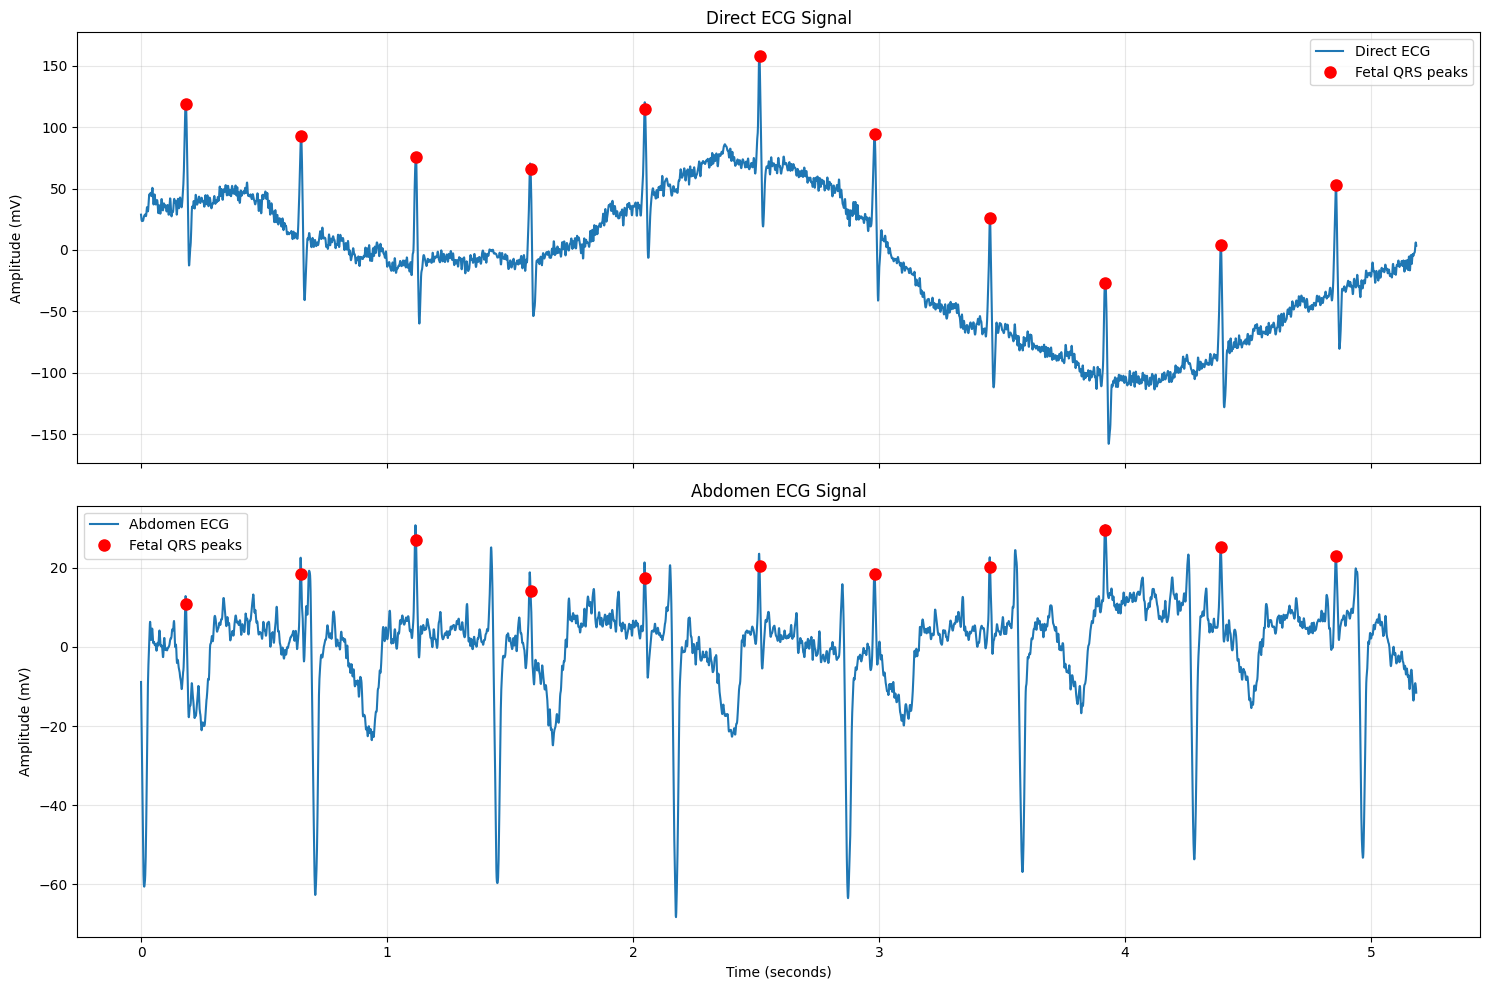

In [5]:
sampling_rate = edf.getSampleFrequency(0)

direct_signal = edf.readSignal(0) # 0 = Direct
abdomen_signal = edf.readSignal(1) # 1 = Abdomen_1, 2 = Abdomen_2, 3 = Abdomen_3, 4 = Abdomen_4
onsets, durations, labels = edf.readAnnotations()

first_onset = onsets[0]
first_label = labels[0]
window_duration = 5.0 # Let's use a bigger window (e.g. 5 or 7 seconds)
start_time = max(0, first_onset - window_duration)
end_time = first_onset + window_duration

# Convert to sample indices
start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extract the signal segment
direct_signal_segment = direct_signal[start_sample:end_sample]
abdomen_signal_segment = abdomen_signal[start_sample:end_sample]
direct_time_segment = np.linspace(start_time, end_time, len(direct_signal_segment))
abdomen_time_segment = np.linspace(start_time, end_time, len(abdomen_signal_segment)) # This should be the same as direct_time_segment

# Get the onsets within the specified time window and interpolate their values
onsets_in_window = onsets[(onsets >= start_time) & (onsets <= end_time)]
direct_onset_values = np.interp(onsets_in_window, direct_time_segment, direct_signal_segment)
abdomen_onset_values = np.interp(onsets_in_window, abdomen_time_segment, abdomen_signal_segment) # This should be the same as direct_onset_values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Direct signal
ax1.plot(direct_time_segment, direct_signal_segment, label='Direct ECG')
ax1.plot(onsets_in_window, direct_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title(f'Direct ECG Signal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Abdomen signal
ax2.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG')
ax2.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude (mV)')
ax2.set_title(f'Abdomen ECG Signal')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

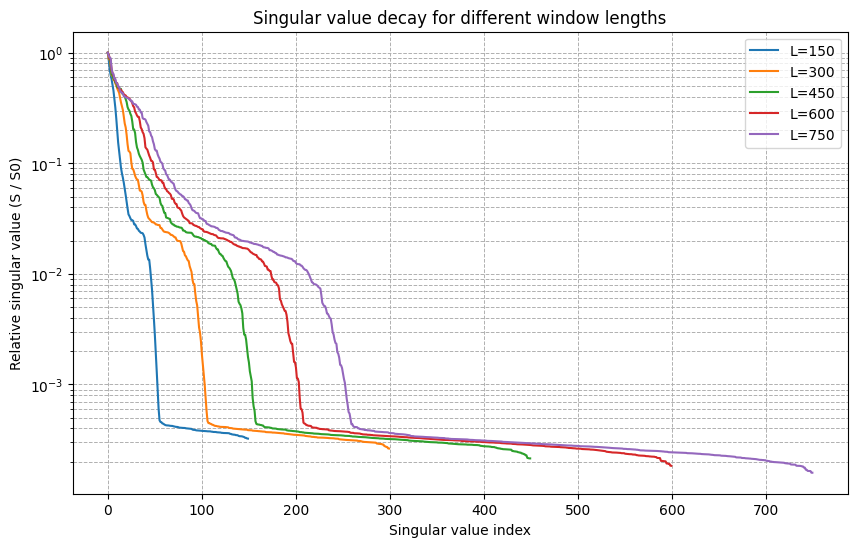

In [18]:
# in this experiment, we will try different window lengths
# for now, we will test with values that can perfectly divide the signal length
L_values = [150, 300, 450, 600, 750]

plt.figure(figsize=(10,6))

for L in L_values:
    X = embed(abdomen_signal_segment, L)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    ratio = S / S[0]
    plt.semilogy(ratio, label=f"L={L}")

plt.xlabel("Singular value index")
plt.ylabel("Relative singular value (S / S0)")
plt.title("Singular value decay for different window lengths")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.show()


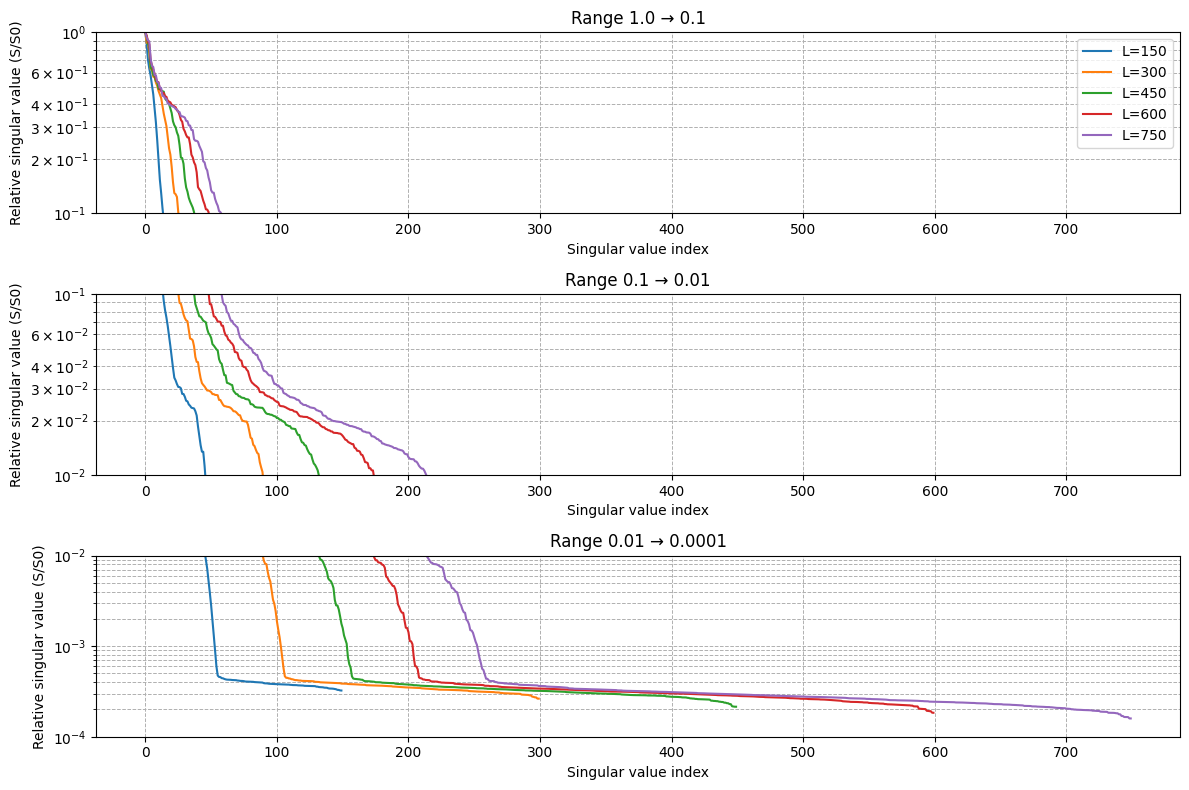

In [27]:
import numpy as np
import matplotlib.pyplot as plt

L_values = [150, 300, 450, 600, 750]

# Define y-axis ranges (log scale)
ranges = [(1e0, 1e-1), (1e-1, 1e-2), (1e-2, 1e-4)]

fig, axes = plt.subplots(3, 1, figsize=(12,8))
axes = axes.flatten()

for ax, (ymax, ymin) in zip(axes, ranges):
    for L in L_values:
        # Build trajectory matrix
        X = embed(abdomen_signal_segment, L)

        # Perform SVD
        U, S, Vt = np.linalg.svd(X, full_matrices=False)

        # Normalize singular values
        ratio = S / S[0]

        # Plot
        ax.semilogy(ratio, label=f"L={L}")
    
    ax.set_ylim(ymin, ymax)   # zoom into the range
    ax.set_xlabel("Singular value index")
    ax.set_ylabel("Relative singular value (S/S0)")
    ax.set_title(f"Range {ymax} → {ymin}")
    ax.grid(True, which="both", linestyle="--", linewidth=0.7)

axes[0].legend()
plt.tight_layout()
plt.show()
